<a href="https://colab.research.google.com/github/anur8591/Netflix-Movie-Recommendation-Engine/blob/main/Netflix2_0(Anurag).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# !pip install surprise

In [3]:
# !pip install numpy==1.26.4

In [4]:
from surprise import SVD, Reader, Dataset
from surprise.model_selection import cross_validate

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
netflix_dataset = pd.read_csv(
    '/content/drive/MyDrive/Netflix/Copy of combined_data_1.txt.zip',
    header=None,
    names=['Cust_Id','Ratings'],
    usecols=[0,1]
)
netflix_dataset.head()

,Cust_Id,Ratings
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [8]:
netflix_dataset.info()
netflix_dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_Id  object 
 1   Ratings  float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


,Ratings
count,2.405376e+07
mean,3.599634e+00
std,1.086118e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00


In [9]:
movie_count = netflix_dataset.isnull().sum()['Ratings']
print("Total Movies:", movie_count)

Total Movies: 4499


In [10]:
total_ids = netflix_dataset['Cust_Id'].nunique()

customer_count = total_ids - movie_count

print("Total Unique IDs:", total_ids)
print("Total Customers:", customer_count)

Total Unique IDs: 475257
Total Customers: 470758


In [11]:
rating_count = netflix_dataset['Cust_Id'].count() - movie_count
print("Total Ratings:", rating_count)

Total Ratings: 24053764


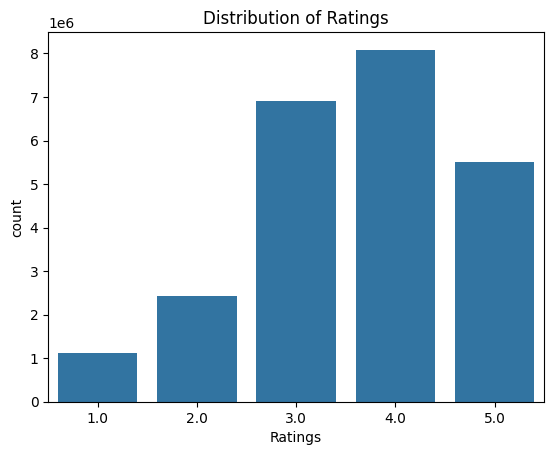

In [12]:
sns.countplot(x='Ratings', data=netflix_dataset)
plt.title("Distribution of Ratings")
plt.show()

In [13]:
movie_id = None
movie_np = []

for x in netflix_dataset['Cust_Id']:
    if ":" in str(x):
        movie_id = int(str(x).replace(":",""))
    movie_np.append(movie_id)
netflix_dataset['Movie_Id'] = movie_np

In [14]:
netflix_dataset.dropna(inplace=True)

In [15]:
netflix_dataset['Cust_Id'] = netflix_dataset['Cust_Id'].astype(int)

In [16]:
netflix_dataset.head()
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Ratings   float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [17]:
movie_review_count = netflix_dataset['Movie_Id'].value_counts()
movie_review_count.head()

,count
Movie_Id,
1905,193941
2152,162597
3860,160454
4432,156183
571,154832


In [18]:
benchmark_movie = round(movie_review_count.quantile(0.6),0)
drop_movie_index = movie_review_count[movie_review_count < benchmark_movie].index

In [19]:
cust_review_count = netflix_dataset['Cust_Id'].value_counts()
benchmark_cust = round(cust_review_count.quantile(0.6),0)
drop_cust_index = cust_review_count[cust_review_count < benchmark_cust].index

In [20]:
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_index)]
netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_index)]
netflix_dataset.head()

,Cust_Id,Ratings,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [22]:
movie_titles = pd.read_csv(
    '/content/drive/MyDrive/Netflix/Copy of movie_titles.csv',
    encoding='ISO-8859-1',
    header=None,
    names=['Movie_Id','Year','Name'],
    usecols=[0,1,2]
)
movie_titles.head()

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [23]:
netflix_dataset = pd.merge(netflix_dataset, movie_titles, on='Movie_Id')
netflix_dataset.head()

,Cust_Id,Ratings,Movie_Id,Year,Name
0,712664,5.0,3,1997.0,Character
1,1331154,4.0,3,1997.0,Character
2,2632461,3.0,3,1997.0,Character
3,44937,5.0,3,1997.0,Character
4,656399,4.0,3,1997.0,Character


In [24]:
reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Ratings']][:100000],reader)

In [25]:
model = SVD()

In [26]:
cross_validate(model, data, measures=['RMSE','MAE'], cv=3)

{'test_rmse': array([1.02478763, 1.01335394, 1.01906363]),
 'test_mae': array([0.81133887, 0.8082767 , 0.81648314]),
 'fit_time': (1.375258445739746, 1.4893510341644287, 2.1361136436462402),
 'test_time': (0.19542145729064941, 0.6553957462310791, 0.2812685966491699)}

In [27]:
trainset = data.build_full_trainset()
model.fit(trainset)

In [28]:
def recommend_movies(user_id, n=10):
    movies = movie_titles.copy()
    movies['Estimated_Rating'] = movies['Movie_Id'].apply(lambda x: model.predict(user_id, x).est)
    movies = movies.sort_values('Estimated_Rating',ascending=False)
    return movies[['Movie_Id','Name','Estimated_Rating']].head(n)


In [29]:
recommend_movies(1331154)

,Movie_Id,Name,Estimated_Rating
24,25,Inspector Morse 31: Death Is Now My Neighbour,4.335361
29,30,Something's Gotta Give,3.900241
4,5,The Rise and Fall of ECW,3.823718
27,28,Lilo and Stitch,3.809639
0,1,Dinosaur Planet,3.665313
11850,11851,The Yearling,3.665313
11849,11850,Dumb and Dumberer: When Harry Met Lloyd,3.665313
11848,11849,Earth,3.665313
11847,11848,For Richer or Poorer,3.665313
11846,11847,Dust to Glory,3.665313
